In [ ]:
import tensorflow as tf
from datasets import load_dataset
import numpy as np
from google.colab import drive
import os
import zipfile

drive.mount('/content/drive')

# Define paths to extract dataset
zip_path = '/content/drive/MyDrive/plated (FYPP)/foodsg-233.zip'
extract_path_base = '/content/foodsg-233_extracted'

# Unzip the dataset to the Colab local environment
if not os.path.exists(extract_path_base):
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path_base)
    print("Extraction complete.")



In [6]:
import PIL
import tensorflow as tf
from datasets import load_dataset
import numpy as np
from google.colab import drive
import os
import zipfile

from PIL import Image

# Use the path defined in the previous cell
# Note: make sure this points to the folder containing the subfolders
check_path = os.path.join(extract_path_base, 'foodsg-233')

print(f"Scanning {check_path} for corrupt images...")
corrupt_files = 0
for root, dirs, files in os.walk(check_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            file_path = os.path.join(root, file)
            try:
                img = Image.open(file_path)
                img.verify()
            except (IOError, SyntaxError):
                print(f'Deleting corrupt file: {file_path}')
                os.remove(file_path)
                corrupt_files += 1
print(f"Done. Deleted {corrupt_files} corrupt images.")



# Adjust extract_path to point to the actual folder containing class subdirectories
# Assuming the zip file extracts into a folder named 'foodsg-233' inside extract_path_base
extract_path = os.path.join(extract_path_base, 'foodsg-233')

# Load the dataset using Keras
# This replaces the Hugging Face 'load_dataset' logic
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Loading dataset from local directory...")
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    extract_path,
    validation_split=0.2, # Adjust split as needed
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    extract_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

# Get class names from the folder structure BEFORE prefetching
class_names = train_ds_raw.class_names
num_classes = len(class_names)
print(f"Loaded {num_classes} classes: {class_names[:5]}...")

# Prefetch for performance
train_ds = train_ds_raw.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds_raw.prefetch(tf.data.AUTOTUNE)


Scanning /content/foodsg-233_extracted/foodsg-233 for corrupt images...


KeyboardInterrupt: 

In [ ]:
# 1. Calculate 10% of the batches
train_10_percent_batches = len(train_ds_raw) // 10
val_10_percent_batches = len(val_ds_raw) // 10

# 2. Select the subset using .take()
small_train_ds = train_ds_raw.take(train_10_percent_batches).prefetch(tf.data.AUTOTUNE)
small_val_ds = val_ds_raw.take(val_10_percent_batches).prefetch(tf.data.AUTOTUNE)

print(f"New training size: {train_10_percent_batches * BATCH_SIZE} images")
print(f"New validation size: {val_10_percent_batches * BATCH_SIZE} images")

In [ ]:
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, BackupAndRestore
import os

# 1. Load the frozen base model
base_model = MobileNetV3Large(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False # Freeze weights for Phase 1

# 2. Build the classification head
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    # CRITICAL: Use num_classes dynamically retrieved in the first cell (233)
    layers.Dense(num_classes, activation='softmax')
])

# 3. Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ---------------------------------------------------------
# Setup Callbacks for Google Drive Saving & Resuming
# ---------------------------------------------------------
checkpoint_dir = '/content/drive/MyDrive/food_classifier_checkpoints(foodsg)'
os.makedirs(checkpoint_dir, exist_ok=True)

# Callback 1: Save the model after every single epoch
checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_dir + "/model-{epoch:02d}-{val_accuracy:.2f}.keras",
    monitor='val_accuracy',
    save_best_only=False,
    verbose=1
)

# Callback 2: Automatic backup
backup_callback = BackupAndRestore(
    backup_dir='/content/drive/MyDrive/food_classifier_backup(foodsg)'
)
# ---------------------------------------------------------

# 2. Train the model using the 10% subset
print("Starting training with automated Drive backups...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[checkpoint_callback, backup_callback]
)

In [7]:
import json

# Save the trained model directly to your Drive
model.save('/content/drive/MyDrive/food_classifier(foodsg).keras')

# Save the class names to your Drive
with open('/content/drive/MyDrive/class_names(foodsg).json', 'w') as f:
    json.dump(class_names, f)

print("✅ Model and class names successfully saved to Google Drive!")

✅ Model and class names successfully saved to Google Drive!


In [8]:
import numpy as np
from sklearn.metrics import classification_report

# 1. Initialize lists to hold our true labels and predictions
y_true = []
y_pred_probs = []

print("Running predictions on the validation dataset...")

# 2. Iterate through the dataset
for images, labels in val_ds:
    # Save the true labels
    y_true.extend(labels.numpy())

    # Generate predictions for this batch
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds)

# 3. Convert lists to numpy arrays and get the predicted class index
y_true = np.array(y_true)
y_pred = np.argmax(y_pred_probs, axis=-1)

# 4. Generate and print the report using the directory class names
print("\nClassification Report:")
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

Running predictions on the validation dataset...

Classification Report:
                                         precision    recall  f1-score   support

                     Alcoholic Beverage       0.80      0.79      0.80       148
                                  Apple       0.64      0.48      0.55       138
                                Apricot       0.54      0.80      0.65        79
                               Avocados       0.86      0.69      0.76       105
                               Ban Mian       0.39      0.49      0.43       101
                                 Barley       0.33      0.16      0.21        83
                       Bee hoon, goreng       0.38      0.59      0.46       300
                         Bee hoon, soto       0.29      0.14      0.19       203
                               Bibimbap       0.60      0.84      0.70       201
                             Blackberry       0.89      0.65      0.75       107
                        Bubble Milk

In [9]:
import json
from google.colab import files

# 1. Save the trained model
# Note: .keras is the modern format for Keras models
model.save('food_classifier(foodsg).keras')

# 2. Save the class names to a JSON file
# (Otherwise, you'd have to load the whole dataset again just to get the names)
with open('class_names(foodsg).json', 'w') as f:
    json.dump(class_names, f)

# 3. Download the files to your local computer
# (Important: Colab deletes files when you close the tab!)
files.download('food_classifier(foodsg).keras')
files.download('class_names(foodsg).json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading saved model from Google Drive...
Loading class names...
✅ System ready! You don't need to retrain.

Please upload a food image for classification:


Saving KP-Hainan-Chicken-Rice-hcgv-videoSixteenByNineJumbo1600.jpg to KP-Hainan-Chicken-Rice-hcgv-videoSixteenByNineJumbo1600.jpg

Processing uploaded file: KP-Hainan-Chicken-Rice-hcgv-videoSixteenByNineJumbo1600.jpg


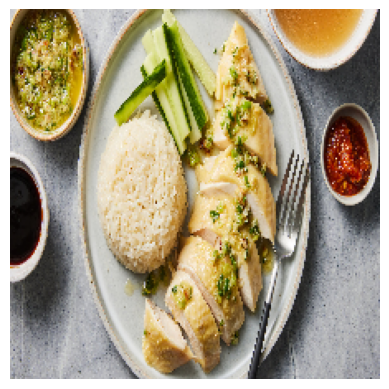

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
🍲 Predicted Food: Chicken Rice
📊 Confidence: 99.84%


In [12]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from google.colab import files
from google.colab import drive # Added this line
from tensorflow.keras.preprocessing import image

drive.mount('/content/drive')

# Define where your files are saved
MODEL_PATH = '/content/drive/MyDrive/food_classifier(foodsg).keras'
CLASS_NAMES_PATH = '/content/drive/MyDrive/class_names(foodsg).json'

# 1. Safely load the Model and Class Names
if os.path.exists(MODEL_PATH) and os.path.exists(CLASS_NAMES_PATH):
    print("Loading saved model from Google Drive...")
    model = tf.keras.models.load_model(MODEL_PATH)

    print("Loading class names...")
    with open(CLASS_NAMES_PATH, 'r') as f:
        class_names = json.load(f)
    print("✅ System ready! You don't need to retrain.\n")
else:
    print("❌ Error: Could not find the saved model or class names.")
    print("Please make sure you have run the training cell successfully and your Google Drive is mounted.")
    raise FileNotFoundError("Missing model or class_names files.")

# 2. Trigger the file upload prompt
print("Please upload a food image for classification:")
uploaded = files.upload()

# 3. Process the uploaded image(s)
for filename in uploaded.keys():
    print(f"\nProcessing uploaded file: {filename}")

    # Load the image and resize to 224x224 (the size MobileNetV3 expects)
    img = image.load_img(filename, target_size=(224, 224))

    # Display the image
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Convert the image to a numpy array and add the batch dimension
    # (MobileNetV3 handles the 0-255 scaling natively)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # 4. Make the prediction
    predictions = model.predict(img_array)

    # 5. Map the prediction to the class name
    predicted_class_idx = np.argmax(predictions, axis=-1)[0]
    predicted_class_name = class_names[predicted_class_idx]
    confidence = predictions[0][predicted_class_idx] * 100

    # 6. Output the result
    print(f"🍲 Predicted Food: {predicted_class_name.replace('_', ' ').title()}")
    print(f"📊 Confidence: {confidence:.2f}%")